# test_Clark_West_test.ipynb

*Latest update by Huei-Wen Teng on 20260222*

*Written by Huei-Wen Teng together with chatGPT on 20260215*

I learned the Clark-West test when revising Yenting & YC work to see if the prediction with powershap feature selection improve prediciton. 

## Things to organize in "topic/Testing prediction errors"

### Demonstration: gitHub/venteng/finalytics/topics

It is more easier to organize if you move all functions in .py files.

1. list_fun_CWtest.py: Example what has been done
2. test_Clark_West_test.ipynb:  Show how the test Clark_West_test.ipynb is implemented in two examples. 



Move all varified functions in the file "list_fun_CWtest.py", import this file to use the functions there.

In [1]:
from list_fun_CWtest import *

I design five functions in list_fun_CWtest 

1. dm_stat, p_value, float(d.mean()) = diebold_mariano_mspe(y_true, f_with, f_without, h=1, max_lag=None)
2. cw_stat, p_value, float(d_cw.mean()) = clark_west_nested(y_true, f_with, f_without, h=1, max_lag=None)
3. y, X = simulate_arx_uniform(T=500, p=10, phi=0.4, b1=1.2, b2=-0.9, b3=0.0, sigma=0.6, seed=42)
4. np.array(y_realized), np.array(f_with), np.array(f_without) = rolling_forecasts(y, X, window=200)
5. pe_with, pe_without = plot_forecasts_3x3_panels(y_true, f_with, f_without, kde_grid=400)

## The Diebold--Mariano (DM) test

To complement the Clark--West analysis, we also report the Diebold--Mariano (DM) test of equal predictive accuracy using mean squared prediction error (MSPE) as the loss function. 

Let the $h$-step-ahead forecast errors under $\text{model}_{\mbox{with}}$ and $\text{model}_{\mbox{without}}$ be
$$e_{t,\text{with}} = r_t(h)-\hat r_{t,\text{with}}(h),
\qquad
e_{t,\text{without}} = r_t(h)-\hat r_{t,\text{without}}(h),
$$
and define the squared-error loss as $L(e)=e^2$. We construct the loss differential as
$$
d_t^{DM} = L(e_{t,\text{without}})-L(e_{t,\text{with}})
= e_{t,\text{without}}^2 - e_{t,\text{with}}^2.
$$

Under this convention, a positive mean differential indicates that feature selection reduces MSPE.

The DM test evaluates
$$
H_0:\ \mathbb{E}\!\left[d_t^{DM}\right]=0
\quad \text{vs} \quad
H_1:\ \mathbb{E}\!\left[d_t^{DM}\right]>0,
$$
where the one-sided alternative reflects that $\text{model}_{\mbox{with}}$ achieves lower MSPE than $\text{model}_{\mbox{without}}$.

Let $\bar d^{DM} = \frac{1}{T}\sum_{t=1}^{T} d_t^{DM}$. The DM statistic is
$$
DM = \frac{\bar d^{DM}}{\sqrt{\widehat{\mathrm{Var}}(\bar d^{DM})}},
$$
where $\widehat{\mathrm{Var}}(\bar d^{DM})$ is estimated using a heteroskedasticity and autocorrelation consistent (HAC) estimator to accommodate serial dependence in $d_t^{DM}$ induced by the rolling-window forecasting design (and by overlapping $h$-step-ahead targets when $h>1$). Under $H_0$, $DM$ is asymptotically standard normal. A significantly positive value of $DM$ supports the conclusion that feature selection improves predictive performance by reducing MSPE.

## The Clark-West test

To formally assess whether powershap improves predictive performance, we employ the Clark--West (2007) adjusted MSPE test, which is appropriate for nested model comparisons in out-of-sample forecasting \citep{clark2007approximately}. In our setting, $\text{model}_{\mbox{with}}$ (with feature selection) is nested within $\text{model}_{\mbox{without}}$ (without feature selection), as the former uses a subset of predictors contained in the latter. The Clark--West procedure corrects for the upward bias in MSPE comparisons that arises from estimation noise in the larger model.\\

The null and alternative hypotheses are defined as
$$
\begin{cases}
H_0: \text{Feature selection does not improve predictive accuracy}, \\
H_1: \text{Feature selection reduces mean squared prediction error}.
\end{cases}
$$

Let the prediction error be
$$
e_{t} = \hat{r}_t(h) - r_t(h),
$$
where $\hat{r}_t(h)$ is the predicted $h$-day-ahead return and $r_t(h)$ is the realized $h$-day-ahead return. Denote by $e_{t,\text{with}}$ and $e_{t,\text{without}}$ the prediction errors from $\text{model}_{\mbox{with}}$ and $\text{model}_{\mbox{without}}$, respectively.

Following \citet{clark2007approximately}, the adjusted loss differential is defined as
$$
d_t^{CW}
=
(e_{t,\text{without}})^2
-
\left[
(e_{t,\text{with}})^2
-
\left(
\hat{r}_{t,\text{with}}(h)
-
\hat{r}_{t,\text{without}}(h)
\right)^2
\right],
$$
which can be equivalently written as
$$
d_t^{CW}
=
(e_{t,\text{without}})^2
-
(e_{t,\text{with}})^2
+
\left(
\hat{r}_{t,\text{with}}(h)
-
\hat{r}_{t,\text{without}}(h)
\right)^2.
$$

Under the null hypothesis, the expected adjusted differential satisfies
$$
H_0: \mathbb{E}[d_t^{CW}] = 0,
\qquad
H_1: \mathbb{E}[d_t^{CW}] > 0.
$$

A positive mean differential therefore indicates that feature selection improves out-of-sample predictive accuracy.

The Clark--West test statistic is
$$
CW
=
\frac{\bar{d}^{CW}}
{\sqrt{\widehat{\mathrm{Var}}(\bar{d}^{CW})}},
\qquad
\bar{d}^{CW}
=
\frac{1}{T}
\sum_{t=1}^{T}
d_t^{CW},
$$
where $\widehat{\mathrm{Var}}(\bar{d}^{CW})$ is computed using a heteroskedasticity and autocorrelation consistent (HAC) estimator to account for serial correlation induced by the rolling-window forecasting procedure. Under $H_0$, the statistic is asymptotically standard normal. A significantly positive value of $CW$ supports the conclusion that powershap enhances predictive performance.

## Simulation studies

Reguested Settings

In [2]:
# =============================
# Requested settings
# =============================
T, p = 500, 10


## Scenario 1: True DGP Uses Only $x_1$ and $x_2$

In this scenario, the data generating process (DGP) is specified as a stationary ARX model:
$$
y_t = \phi y_{t-1} + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \varepsilon_t,
$$

where
* $$x_{i,t} \sim \text{Uniform}(0,1)$$ for $$i = 1,\ldots,10$$,
* $$\varepsilon_t \sim \mathcal{N}(0,\sigma^2)$$,
* $$|\phi| < 1$$ to ensure stationarity.

Importantly, only $$x_1$$ and $$x_2$$ enter the true model. The remaining predictors $$x_3, \ldots, x_{10}$$ contain no signal and are pure noise.

---

### Model Comparison

We compare two nested forecasting models:

* **$\text{model}_{\text{with}}$** (feature-selected model):

  $$
  y_t = \alpha + \phi y_{t-1} + \beta_1 x_{1,t} + \beta_2 x_{2,t} + u_t
  $$

* **$\text{model}_{\text{without}}$** (full model):

  $$
  y_t = \alpha + \phi y_{t-1} + \sum_{i=1}^{10} \beta_i x_{i,t} + u_t
  $$

Because the true DGP depends only on $x_1$ and $x_2$, the smaller model is correctly specified. The larger model includes additional irrelevant regressors.

Thus, the nesting relationship is:

$$
\text{model}*{\text{with}} \subset \text{model}*{\text{without}}.
$$

---

### Expected Clark–West Outcome

Under this scenario:

* The additional regressors in $\text{model}_{\text{without}}$ contain no predictive information.
* The larger model may exhibit slightly higher in-sample fit due to overfitting.
* However, out-of-sample MSPE should not improve.

The Clark–West adjusted loss differential is

$$
d_t^{CW}
========

## (e_{t,\text{with}})^2

(e_{t,\text{without}})^2
+
(\hat{y}*{t,\text{with}} - \hat{y}*{t,\text{without}})^2.
$$

Under the null hypothesis,

$$
H_0: \mathbb{E}[d_t^{CW}] = 0,
$$

meaning that the larger model does not improve predictive accuracy.

Since the extra predictors are irrelevant, we expect:

$$
\mathbb{E}[d_t^{CW}] \le 0,
$$

and therefore the Clark–West statistic should not be significantly positive.

---

### Interpretation

If the Clark–West test statistic is:

* Negative or close to zero,
* With a large one-sided p-value,

this confirms that the additional predictors do not improve forecasting performance.

This scenario validates that the Clark–West test correctly avoids falsely favoring a larger nested model when the additional regressors contain no true signal.


In [3]:
# y1 only depends on x1 and x2. 
y1, X1 = simulate_arx_uniform(T=T, p=p, phi=0.4, b1=1.2, b2=-0.9, b3=0.0, sigma=0.6, seed=123)

In [4]:
# Now you can use the rolling_forecasts function that depends on 
# f_with1: With the only true x1 and x2
# f_without1: Using x1, ..., xp as predictors 

y_true1, f_with1, f_without1 = rolling_forecasts(y1, X1, window=200)


In [5]:
dm_stat, pval, dbar = diebold_mariano_mspe(y_true1, f_with1, f_without1, h=1)

print("DM statistic:", dm_stat)
print("One-sided p-value:", pval)
print("Mean loss differential:", dbar)

DM statistic: 2.846271841904402
One-sided p-value: 0.0022117207633871594
Mean loss differential: 0.020132903682188476


In [6]:
cw_stat1, pval1, dbar1 = clark_west_nested(y_true1, f_with1, f_without1, h=1)

print("=== Scenario 1: True model uses x1,x2 only ===")
print(f"CW statistic (H1: model_without improves over model_with) = {cw_stat1: .3f}")
print(f"One-sided p-value                                         = {pval1: .4f}")
print(f"Mean adjusted differential (estimate)                      = {dbar1: .6f}\n")

=== Scenario 1: True model uses x1,x2 only ===
CW statistic (H1: model_without improves over model_with) =  4.286
One-sided p-value                                         =  0.0000
Mean adjusted differential (estimate)                      =  0.030932



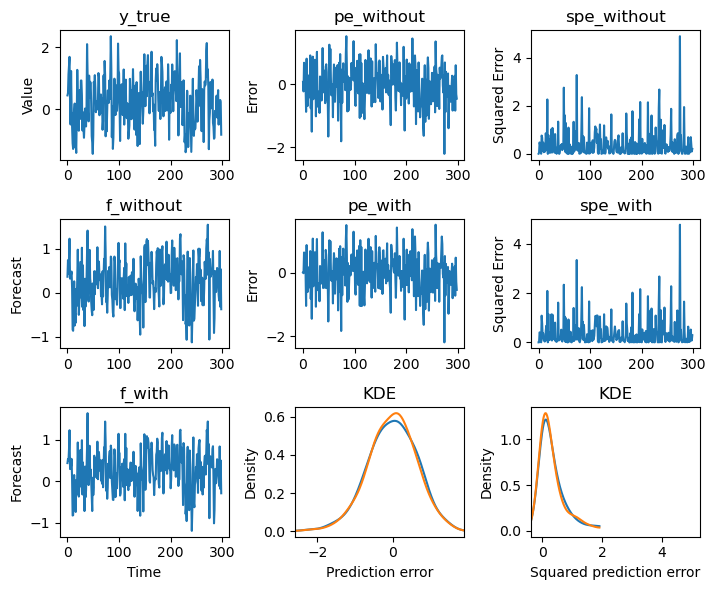

In [7]:
pe_with1, pe_without1 = plot_forecasts_3x3_panels(y_true1, f_with1, f_without1)